In [1]:

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess, sys, shlex

def pip_install(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *args]
    subprocess.check_call(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Core packages
for args in [
    ["--upgrade", "huggingface_hub"],
    ["--upgrade", "transformers"],
    ["--upgrade", "accelerate"],
    ["--upgrade", "bitsandbytes"],
    ["--upgrade", "sentencepiece"],
    ["openpyxl"], ["pandas"], ["numpy"], ["scikit-learn"],
    ["matplotlib"], ["rouge-score"], ["nltk"],
]:
    pip_install(*args)

# Unsloth with pinned deps
subprocess.run([sys.executable, "-m", "pip", "uninstall", "unsloth", "unsloth-zoo", "-y", "-q"], check=False, capture_output=True)
pip_install("datasets>=3.4.1,<4.4.0")
pip_install("trl>=0.18.2,<=0.24.0")
pip_install("unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git")



All packages installed
Restart kernel once: Kernel -> Restart Kernel
Then run from Cell 2 onwards


In [2]:

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from huggingface_hub import login

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Logged in via HF_TOKEN env var")
else:
    login()

import pandas as pd
import json

# Verify all required files exist
required = [
    "baseline_outputs.csv",
    "finetuned_outputs.csv",
    "train_coaching.csv",
    "val_coaching.csv",
    "test_coaching.csv",
    "test_ids_locked.json",
    "train_formatted.json",
    "val_formatted.json",
]

print("\nFile check:")
all_ok = True
for f in required:
    exists = os.path.exists(f)
    size = f"{os.path.getsize(f)/1024:.1f} KB" if exists else "MISSING"
    status = "ok" if exists else "MISSING"
    print(f"  {f:<30} {size:<12} {status}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAll files present")
else:
    print("\nSome files missing! Upload them before continuing.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in via HF_TOKEN env var

File check:
  baseline_outputs.csv           271.0 KB     ok
  finetuned_outputs.csv          249.1 KB     ok
  train_coaching.csv             706.7 KB     ok
  val_coaching.csv               153.8 KB     ok
  test_coaching.csv              151.8 KB     ok
  test_ids_locked.json           1.2 KB       ok
  train_formatted.json           897.4 KB     ok
  val_formatted.json             194.6 KB     ok

All files present


In [1]:

import json, numpy as np
from datasets import Dataset

with open("train_formatted.json") as f:
    train_formatted = json.load(f)
with open("val_formatted.json") as f:
    val_formatted = json.load(f)

train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)

# Token estimate
estimates = [int(len(" ".join([m['content'] for m in ex['messages']]).split())*1.3) for ex in train_formatted]
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Token estimates -- Min:{min(estimates)} Max:{max(estimates)} Mean:{np.mean(estimates):.0f}")
print(f"Examples > 768 tokens: {len([t for t in estimates if t > 768])}")
print(f"Examples > 1024 tokens: {len([t for t in estimates if t > 1024])}")




Train: 210 | Val: 45
Token estimates -- Min:449 Max:2021 Mean:837
Examples > 768 tokens: 127
Examples > 1024 tokens: 28

>>> Switch to L4 GPU now, then run Cell 4 <<<


In [3]:
#

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import unsloth  # MUST be first
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
import torch, gc, json, time
from datasets import load_from_disk, Dataset
from trl import SFTTrainer, SFTConfig

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"GPU used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Load datasets
with open("train_formatted.json") as f:
    train_dataset = Dataset.from_list(json.load(f))
with open("val_formatted.json") as f:
    val_dataset = Dataset.from_list(json.load(f))
print(f"Datasets: train={len(train_dataset)} val={len(val_dataset)}")

# ---- MEMORY-SAFE SETTINGS FOR 9B ON L4 ----
MODEL_NAME = "Qwen/Qwen3.5-9B-Base"
MAX_SEQ_LENGTH = 768    # Aggressive but needed for 9B on 24GB
LORA_RANK = 8           # Lower rank = less memory

print(f"\nLoading {MODEL_NAME}...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
    trust_remote_code=True,
)
print(f"Base model loaded -- GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Attach LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha=16,          # 2x rank
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"LoRA attached -- trainable: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"GPU used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# Apply chat template
tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")

def apply_template(examples):
    texts = [
        tokenizer.apply_chat_template(ex, tokenize=False, add_generation_prompt=False)
        for ex in examples["messages"]
    ]
    return {"text": texts}

train_dataset = train_dataset.map(apply_template, batched=True)
val_dataset = val_dataset.map(apply_template, batched=True)
print("Chat template applied")

# MEMORY-SAFE TRAINING 
training_args = SFTConfig(
    output_dir="qwen9b_coaching_lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,      
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,      
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    gradient_checkpointing=True,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,
    eval_strategy="no",                 # DISABLED to avoid memory spikes
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=10,
    report_to="none",
    seed=42,
)

trainer = SFTTrainer(
    model=model, tokenizer=tokenizer,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    args=training_args,
)

steps_per_epoch = len(train_dataset) // (
    training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
print(f"\nSteps/epoch: {steps_per_epoch} | Total: {steps_per_epoch*3}")

# Clear cache before training
torch.cuda.empty_cache()
gc.collect()
print(f"GPU before training: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print("\nStarting training (expect 45-90 min on L4)...")
t_start = time.time()
trainer_stats = trainer.train()
elapsed = (time.time() - t_start) / 60

print(f"\nTraining complete -- {elapsed:.1f} min")
print(f"Final train loss: {trainer_stats.training_loss:.4f}")

# Save adapters
model.save_pretrained("qwen9b_coaching_lora_final")
tokenizer.save_pretrained("qwen9b_coaching_lora_final")
print("LoRA adapters saved to qwen9b_coaching_lora_final/")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
GPU: NVIDIA L4
GPU memory: 23.7 GB
GPU used: 0.00 GB
Datasets: train=210 val=45

Loading Qwen/Qwen3.5-9B-Base...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.18: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Qwen3_5 does not support SDPA - switching to fast eager.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

...


Steps/epoch: 26 | Total: 78


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248044}.


GPU before training: 8.00 GB

Starting training (expect 45-90 min on L4)...
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,12.674394
20,10.133326
30,8.540099
40,8.801035
50,8.595161
60,7.763988
70,8.169788
80,7.987226



Training complete -- 31.7 min
Final train loss: 8.9992
LoRA adapters saved to qwen9b_coaching_lora_final/


In [4]:

FastLanguageModel.for_inference(model)

SYSTEM_PROMPT = "You are an expert communication coach specializing in charitable persuasion conversations. Your role is to analyze a conversation between a persuader and a persuadee, where the persuader is trying to convince the persuadee to donate to Save the Children charity.\n\nProvide structured coaching feedback to the persuader covering:\n1. Overall performance assessment\n2. What communication strategies worked well\n3. Areas that need improvement\n4. Specific actionable suggestions for future conversations\n\nBe specific, reference the actual conversation, and focus on persuasion effectiveness."

# Unwrap tokenizer (Unsloth wraps it in a processor)
chat_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

print(f"tokenizer type: {type(tokenizer)}")
print(f"chat_tokenizer type: {type(chat_tokenizer)}")

# Test with typed content blocks (fixes "string indices must be integers")
sample_msgs = [
    {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
    {"role": "user", "content": [{"type": "text", "text": "test conversation"}]},
]

sample_prompt = chat_tokenizer.apply_chat_template(
    sample_msgs, tokenize=False, add_generation_prompt=True
)
print(f"\nTemplate test passed. Output (first 300 chars):")
print(sample_prompt[:300])



tokenizer type: <class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
chat_tokenizer type: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>

Template test passed. Output (first 300 chars):
<|im_start|>system
You are an expert communication coach specializing in charitable persuasion conversations. Your role is to analyze a conversation between a persuader and a persuadee, where the persuader is trying to convince the persuadee to donate to Save the Children charity.

Provide structure


In [5]:


import pandas as pd
import torch, gc, time

test_df = pd.read_csv("test_coaching.csv")
print(f"Test set: {len(test_df)} conversations")

def build_prompt(conv_text):
    return f"Analyze the following persuasion conversation and provide detailed coaching feedback for the persuader:\n\n--- CONVERSATION START ---\n{conv_text}\n--- CONVERSATION END ---\n\nProvide your coaching feedback now."

# Use unwrapped tokenizer (from Cell 5)
finetuned9b_results, failed_ids = [], []

for i, (_, row) in enumerate(test_df.iterrows()):
    t0 = time.time()
    try:
        conv_text = "" if pd.isna(row["conversation_text"]) else str(row["conversation_text"])

        msgs = [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {"role": "user", "content": [{"type": "text", "text": build_prompt(conv_text)}]},
        ]

        prompt_text = chat_tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True,
        )
        inputs = chat_tokenizer(prompt_text, return_tensors="pt").to(model.device)

        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=512,
                temperature=0.3,
                do_sample=True,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=chat_tokenizer.eos_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        resp = chat_tokenizer.decode(out[0][input_len:], skip_special_tokens=True)

        finetuned9b_results.append({
            "dialogue_id": row["dialogue_id"],
            "donated": row["donated"],
            "actual_amount": row["actual_amount"],
            "conversation_text": conv_text,
            "reference_feedback": row["coaching_feedback"],
            "finetuned9b_feedback": resp,
            "input_tokens": int(input_len),
            "output_word_count": len(resp.split()),
            "inference_time_s": round(time.time()-t0, 2),
        })
        print(f"  [{i+1:02d}/45] OK ({len(resp.split())} words, {time.time()-t0:.1f}s)")

    except Exception as e:
        failed_ids.append(row.get("dialogue_id", f"row_{i}"))
        print(f"  [{i+1:02d}/45] FAILED -- {repr(e)}")

    if (i+1) % 10 == 0:
        torch.cuda.empty_cache(); gc.collect()

df_finetuned9b = pd.DataFrame(finetuned9b_results)
df_finetuned9b.to_csv("finetuned9b_outputs.csv", index=False)
print(f"\nfinetuned9b_outputs.csv saved -- {len(df_finetuned9b)} rows, {len(failed_ids)} failed")



Test set: 45 conversations
  [01/45] OK (253 words, 55.7s)
  [02/45] OK (261 words, 57.0s)
  [03/45] OK (330 words, 69.2s)
  [04/45] OK (316 words, 67.2s)
  [05/45] OK (342 words, 72.4s)
  [06/45] OK (334 words, 72.5s)
  [07/45] OK (347 words, 70.7s)
  [08/45] OK (311 words, 61.3s)
  [09/45] OK (275 words, 57.1s)
  [10/45] OK (343 words, 72.1s)
  [11/45] OK (352 words, 72.4s)
  [12/45] OK (332 words, 71.9s)
  [13/45] OK (360 words, 72.4s)
  [14/45] OK (354 words, 72.3s)
  [15/45] OK (232 words, 48.4s)
  [16/45] OK (293 words, 61.4s)
  [17/45] OK (314 words, 62.3s)
  [18/45] OK (298 words, 64.4s)
  [19/45] OK (318 words, 64.1s)
  [20/45] OK (331 words, 72.6s)
  [21/45] OK (357 words, 71.8s)
  [22/45] OK (335 words, 71.0s)
  [23/45] OK (348 words, 72.2s)
  [24/45] OK (258 words, 55.1s)
  [25/45] OK (337 words, 71.3s)
  [26/45] OK (304 words, 64.9s)
  [27/45] OK (313 words, 66.0s)
  [28/45] OK (325 words, 67.3s)
  [29/45] OK (323 words, 66.9s)
  [30/45] OK (358 words, 71.8s)
  [31/45] OK 

In [6]:


import pandas as pd
import numpy as np
import re
from rouge_score import rouge_scorer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

# Load all three output files
df_baseline = pd.read_csv("baseline_outputs.csv")
df_ft4b = pd.read_csv("finetuned_outputs.csv")
df_ft9b = pd.read_csv("finetuned9b_outputs.csv")

print(f"Baseline (9B Instruct) : {len(df_baseline)} rows")
print(f"Fine-tuned 4B          : {len(df_ft4b)} rows")
print(f"Fine-tuned 9B          : {len(df_ft9b)} rows")

# Build maps by dialogue_id
baseline_map = dict(zip(df_baseline['dialogue_id'], df_baseline['baseline_feedback']))

# Handle column name differences
ft4b_col = 'finetuned_feedback' if 'finetuned_feedback' in df_ft4b.columns else [c for c in df_ft4b.columns if 'finetuned' in c.lower() and 'feedback' in c.lower()][0]
ft9b_col = 'finetuned9b_feedback' if 'finetuned9b_feedback' in df_ft9b.columns else [c for c in df_ft9b.columns if 'finetuned' in c.lower() and 'feedback' in c.lower()][0]

ft4b_map = dict(zip(df_ft4b['dialogue_id'], df_ft4b[ft4b_col]))
ft9b_map = dict(zip(df_ft9b['dialogue_id'], df_ft9b[ft9b_col]))

# Reference feedback (from any of the three — they all have it)
ref_col = 'reference_feedback' if 'reference_feedback' in df_baseline.columns else 'coaching_feedback'
reference_map = dict(zip(df_baseline['dialogue_id'], df_baseline[ref_col]))

# Common IDs across all three
common_ids = sorted(set(baseline_map.keys()) & set(ft4b_map.keys()) & set(ft9b_map.keys()))
print(f"\nCommon test conversations across all 3 models: {len(common_ids)}")

references = [str(reference_map[did]) for did in common_ids]
baselines  = [str(baseline_map[did]) for did in common_ids]
ft4bs      = [str(ft4b_map[did]) for did in common_ids]
ft9bs      = [str(ft9b_map[did]) for did in common_ids]

# ROUGE computation
def compute_rouge(preds, refs):
    r1,r2,rL = [],[],[]
    for p,r in zip(preds, refs):
        s = scorer.score(r, p)
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rL.append(s['rougeL'].fmeasure)
    return {'rouge1':round(np.mean(r1),4), 'rouge2':round(np.mean(r2),4), 'rougeL':round(np.mean(rL),4)}

rouge_bl  = compute_rouge(baselines, references)
rouge_4b  = compute_rouge(ft4bs, references)
rouge_9b  = compute_rouge(ft9bs, references)

print(f"\n{'Metric':<12} {'9B Instruct':>12} {'4B FT':>12} {'9B FT':>12} {'Best':>10}")
print("-" * 60)
for m in ['rouge1','rouge2','rougeL']:
    b, f4, f9 = rouge_bl[m], rouge_4b[m], rouge_9b[m]
    best_val = max(b, f4, f9)
    best_name = "9B-Inst" if b==best_val else "4B-FT" if f4==best_val else "9B-FT"
    print(f"{m:<12} {b:>12.4f} {f4:>12.4f} {f9:>12.4f} {best_name:>10}")

# Content quality metrics
def quality_metrics(feedbacks):
    n = len(feedbacks)
    has_overall = sum(1 for fb in feedbacks if any(kw in str(fb).lower() for kw in ['overall','performance','assessment']))
    has_strengths = sum(1 for fb in feedbacks if any(kw in str(fb).lower() for kw in ['worked','strength','effective','well']))
    has_weaknesses = sum(1 for fb in feedbacks if any(kw in str(fb).lower() for kw in ['improv','weakness','didn']))
    has_suggestions = sum(1 for fb in feedbacks if any(kw in str(fb).lower() for kw in ['suggest','recommend','try','consider','tip']))
    return {
        'overall_%': round(has_overall/n*100,1),
        'strengths_%': round(has_strengths/n*100,1),
        'weaknesses_%': round(has_weaknesses/n*100,1),
        'suggestions_%': round(has_suggestions/n*100,1),
        'avg_words': round(np.mean([len(str(fb).split()) for fb in feedbacks]),1),
    }

q_bl = quality_metrics(baselines)
q_4b = quality_metrics(ft4bs)
q_9b = quality_metrics(ft9bs)

print(f"\n{'Metric':<22} {'9B Instruct':>12} {'4B FT':>12} {'9B FT':>12}")
print("-" * 60)
for key in ['overall_%','strengths_%','weaknesses_%','suggestions_%','avg_words']:
    print(f"{key:<22} {q_bl[key]:>12} {q_4b[key]:>12} {q_9b[key]:>12}")

# Save comparison report
import json
report = {
    "experiment": "3-Way Comparison: 9B Instruct vs 4B Fine-tuned vs 9B Fine-tuned",
    "test_conversations": len(common_ids),
    "rouge": {"baseline": rouge_bl, "finetuned_4b": rouge_4b, "finetuned_9b": rouge_9b},
    "quality": {"baseline": q_bl, "finetuned_4b": q_4b, "finetuned_9b": q_9b},
}
with open("comparison_report_3way.json","w") as f:
    json.dump(report, f, indent=2)
print("\ncomparison_report_3way.json saved")


Baseline (9B Instruct) : 45 rows
Fine-tuned 4B          : 45 rows
Fine-tuned 9B          : 45 rows

Common test conversations across all 3 models: 45

Metric        9B Instruct        4B FT        9B FT       Best
------------------------------------------------------------
rouge1             0.3478       0.5820       0.5690      4B-FT
rouge2             0.0458       0.3339       0.3198      4B-FT
rougeL             0.1305       0.3693       0.3523      4B-FT

Metric                  9B Instruct        4B FT        9B FT
------------------------------------------------------------
overall_%                     100.0        100.0        100.0
strengths_%                   100.0        100.0        100.0
weaknesses_%                  100.0        100.0        100.0
suggestions_%                 100.0        100.0        100.0
avg_words                     272.4        299.6        314.4

comparison_report_3way.json saved


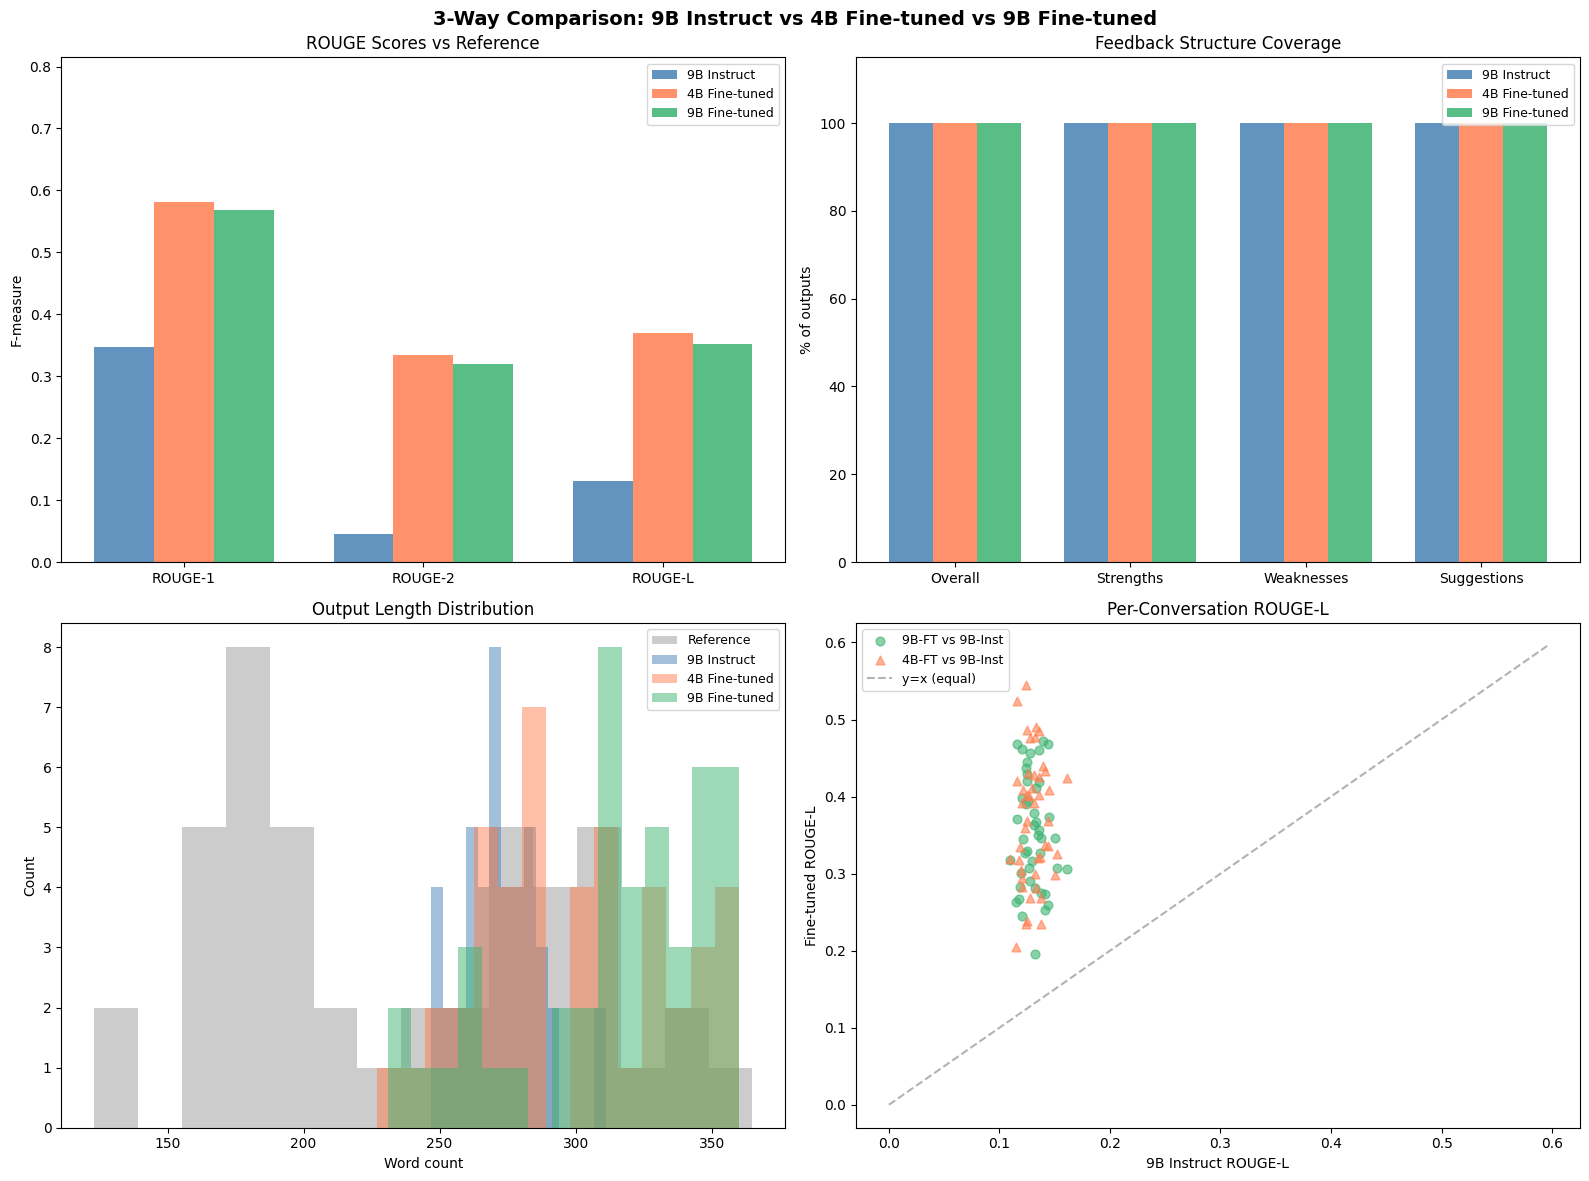

comparison_3way.png saved

EXPERIMENT COMPLETE -- 3-WAY COMPARISON

Test set: 45 conversations

Model                   ROUGE-1    ROUGE-2    ROUGE-L  Avg Words
-----------------------------------------------------------------
9B Instruct              0.3478     0.0458     0.1305      272.4
4B Fine-tuned            0.5820     0.3339     0.3693      299.6
9B Fine-tuned            0.5690     0.3198     0.3523      314.4
  rouge1 winner: 4B Fine-tuned (0.5820)
  rouge2 winner: 4B Fine-tuned (0.3339)
  rougeL winner: 4B Fine-tuned (0.3693)
  comparison_report_3way.json
  comparison_3way.png


In [7]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("3-Way Comparison: 9B Instruct vs 4B Fine-tuned vs 9B Fine-tuned",
             fontsize=14, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['9B Instruct', '4B Fine-tuned', '9B Fine-tuned']

# Chart 1: ROUGE scores
ax = axes[0,0]
metrics_names = ['ROUGE-1','ROUGE-2','ROUGE-L']
vals = [[rouge_bl['rouge1'],rouge_bl['rouge2'],rouge_bl['rougeL']],
        [rouge_4b['rouge1'],rouge_4b['rouge2'],rouge_4b['rougeL']],
        [rouge_9b['rouge1'],rouge_9b['rouge2'],rouge_9b['rougeL']]]
x = np.arange(len(metrics_names)); w = 0.25
for j,(v,c,l) in enumerate(zip(vals,colors,labels)):
    ax.bar(x + j*w - w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel('F-measure'); ax.set_title('ROUGE Scores vs Reference')
ax.legend(fontsize=9); ax.set_ylim(0, max(max(v) for v in vals)*1.4)

# Chart 2: Structure coverage
ax = axes[0,1]
struct_keys = ['overall_%','strengths_%','weaknesses_%','suggestions_%']
struct_labels = ['Overall','Strengths','Weaknesses','Suggestions']
vals_s = [[q_bl[k] for k in struct_keys],
          [q_4b[k] for k in struct_keys],
          [q_9b[k] for k in struct_keys]]
x2 = np.arange(len(struct_labels))
for j,(v,c,l) in enumerate(zip(vals_s,colors,labels)):
    ax.bar(x2 + j*w - w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(struct_labels)
ax.set_ylabel('% of outputs'); ax.set_title('Feedback Structure Coverage')
ax.legend(fontsize=9); ax.set_ylim(0, 115)

# Chart 3: Word count distributions
ax = axes[1,0]
ref_wc = [len(str(r).split()) for r in references]
bl_wc = [len(str(b).split()) for b in baselines]
f4_wc = [len(str(f).split()) for f in ft4bs]
f9_wc = [len(str(f).split()) for f in ft9bs]
ax.hist(ref_wc, bins=15, alpha=0.4, label='Reference', color='gray')
ax.hist(bl_wc, bins=15, alpha=0.5, label='9B Instruct', color='steelblue')
ax.hist(f4_wc, bins=15, alpha=0.5, label='4B Fine-tuned', color='coral')
ax.hist(f9_wc, bins=15, alpha=0.5, label='9B Fine-tuned', color='mediumseagreen')
ax.set_xlabel('Word count'); ax.set_ylabel('Count')
ax.set_title('Output Length Distribution'); ax.legend(fontsize=9)

# Chart 4: Per-conversation ROUGE-L scatter (9B-FT vs 9B-Instruct)
ax = axes[1,1]
per_bl = [scorer.score(r,b)['rougeL'].fmeasure for r,b in zip(references,baselines)]
per_9b = [scorer.score(r,f)['rougeL'].fmeasure for r,f in zip(references,ft9bs)]
per_4b = [scorer.score(r,f)['rougeL'].fmeasure for r,f in zip(references,ft4bs)]
ax.scatter(per_bl, per_9b, alpha=0.6, s=40, c='mediumseagreen', label='9B-FT vs 9B-Inst')
ax.scatter(per_bl, per_4b, alpha=0.6, s=40, c='coral', marker='^', label='4B-FT vs 9B-Inst')
mx = max(max(per_bl), max(per_9b), max(per_4b)) + 0.05
ax.plot([0,mx],[0,mx],'k--',alpha=0.3, label='y=x (equal)')
ax.set_xlabel('9B Instruct ROUGE-L'); ax.set_ylabel('Fine-tuned ROUGE-L')
ax.set_title('Per-Conversation ROUGE-L'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("comparison_3way.png", dpi=150, bbox_inches='tight')
plt.show()
print("comparison_3way.png saved")

# Final summary
print("\n" + "="*65)
print("EXPERIMENT COMPLETE -- 3-WAY COMPARISON")
print("="*65)
print(f"\nTest set: {len(common_ids)} conversations")
print(f"\n{'Model':<20} {'ROUGE-1':>10} {'ROUGE-2':>10} {'ROUGE-L':>10} {'Avg Words':>10}")
print("-"*65)
print(f"{'9B Instruct':<20} {rouge_bl['rouge1']:>10.4f} {rouge_bl['rouge2']:>10.4f} {rouge_bl['rougeL']:>10.4f} {q_bl['avg_words']:>10.1f}")
print(f"{'4B Fine-tuned':<20} {rouge_4b['rouge1']:>10.4f} {rouge_4b['rouge2']:>10.4f} {rouge_4b['rougeL']:>10.4f} {q_4b['avg_words']:>10.1f}")
print(f"{'9B Fine-tuned':<20} {rouge_9b['rouge1']:>10.4f} {rouge_9b['rouge2']:>10.4f} {rouge_9b['rougeL']:>10.4f} {q_9b['avg_words']:>10.1f}")

# Determine winners
for m in ['rouge1','rouge2','rougeL']:
    scores = {'9B Instruct':rouge_bl[m], '4B Fine-tuned':rouge_4b[m], '9B Fine-tuned':rouge_9b[m]}
    winner = max(scores, key=scores.get)
    print(f"  {m} winner: {winner} ({scores[winner]:.4f})")


print("  comparison_report_3way.json")
print("  comparison_3way.png")


In [8]:

import subprocess, sys

def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

pip_install("rouge-score")
pip_install("bert-score")
pip_install("nltk")
pip_install("pandas")
pip_install("numpy")
pip_install("matplotlib")
pip_install("scipy")

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)




True

In [9]:

import pandas as pd
import numpy as np
import json, os, re

df_bl = pd.read_csv("baseline_outputs.csv")
df_4b = pd.read_csv("finetuned_outputs.csv")
df_9b = pd.read_csv("finetuned9b_outputs.csv")

print(f"Baseline (9B Instruct)  : {len(df_bl)} rows")
print(f"Fine-tuned 4B           : {len(df_4b)} rows")
print(f"Fine-tuned 9B           : {len(df_9b)} rows")


def find_feedback_col(df, keywords):
    for c in df.columns:
        if any(kw in c.lower() for kw in keywords):
            return c
    return None

bl_col = find_feedback_col(df_bl, ['baseline_feedback', 'baseline'])
f4_col = find_feedback_col(df_4b, ['finetuned_feedback', 'finetuned'])
f9_col = find_feedback_col(df_9b, ['finetuned9b_feedback', 'finetuned'])
ref_col = find_feedback_col(df_bl, ['reference_feedback', 'coaching_feedback', 'reference'])

print(f"\nColumn mapping:")
print(f"  Baseline feedback : {bl_col}")
print(f"  4B FT feedback    : {f4_col}")
print(f"  9B FT feedback    : {f9_col}")
print(f"  Reference feedback: {ref_col}")

# arrays by dialogue_id
bl_map = dict(zip(df_bl['dialogue_id'], df_bl[bl_col].astype(str)))
f4_map = dict(zip(df_4b['dialogue_id'], df_4b[f4_col].astype(str)))
f9_map = dict(zip(df_9b['dialogue_id'], df_9b[f9_col].astype(str)))
ref_map = dict(zip(df_bl['dialogue_id'], df_bl[ref_col].astype(str)))

# donation outcome
donated_map = dict(zip(df_bl['dialogue_id'], df_bl['donated']))

common_ids = sorted(set(bl_map) & set(f4_map) & set(f9_map))
print(f"\nCommon dialogue IDs across all 3 models: {len(common_ids)}")

references = [ref_map[d] for d in common_ids]
baselines  = [bl_map[d] for d in common_ids]
ft4bs      = [f4_map[d] for d in common_ids]
ft9bs      = [f9_map[d] for d in common_ids]
donated    = [donated_map[d] for d in common_ids]

# null values
for name, arr in [("Reference",references),("Baseline",baselines),("4B-FT",ft4bs),("9B-FT",ft9bs)]:
    empty = sum(1 for x in arr if len(x.strip()) < 10)
    print(f"  {name}: {empty} near-empty outputs out of {len(arr)}")




Baseline (9B Instruct)  : 45 rows
Fine-tuned 4B           : 45 rows
Fine-tuned 9B           : 45 rows

Column mapping:
  Baseline feedback : baseline_feedback
  4B FT feedback    : finetuned_feedback
  9B FT feedback    : finetuned9b_feedback
  Reference feedback: reference_feedback

Common dialogue IDs across all 3 models: 45
  Reference: 0 near-empty outputs out of 45
  Baseline: 0 near-empty outputs out of 45
  4B-FT: 0 near-empty outputs out of 45
  9B-FT: 0 near-empty outputs out of 45


In [10]:

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

def compute_rouge_detailed(preds, refs):
    results = {'rouge1_p':[],'rouge1_r':[],'rouge1_f':[],
               'rouge2_p':[],'rouge2_r':[],'rouge2_f':[],
               'rougeL_p':[],'rougeL_r':[],'rougeL_f':[]}
    for p, r in zip(preds, refs):
        s = scorer.score(r, p)
        for metric in ['rouge1','rouge2','rougeL']:
            results[f'{metric}_p'].append(s[metric].precision)
            results[f'{metric}_r'].append(s[metric].recall)
            results[f'{metric}_f'].append(s[metric].fmeasure)
    return {k: np.array(v) for k, v in results.items()}

rouge_bl = compute_rouge_detailed(baselines, references)
rouge_4b = compute_rouge_detailed(ft4bs, references)
rouge_9b = compute_rouge_detailed(ft9bs, references)

print("=" * 75)
print("ROUGE SCORES (mean +/- std)")
print("=" * 75)
print(f"{'Metric':<14} {'9B Instruct':>18} {'4B Fine-tuned':>18} {'9B Fine-tuned':>18}")
print("-" * 75)

for metric_base in ['rouge1', 'rouge2', 'rougeL']:
    for suffix, label in [('_p','Precision'),('_r','Recall'),('_f','F1')]:
        key = metric_base + suffix
        bl_m, bl_s = rouge_bl[key].mean(), rouge_bl[key].std()
        f4_m, f4_s = rouge_4b[key].mean(), rouge_4b[key].std()
        f9_m, f9_s = rouge_9b[key].mean(), rouge_9b[key].std()
        row_label = f"{metric_base} {label}"
        print(f"{row_label:<14} {bl_m:>7.4f} +/- {bl_s:.4f}   {f4_m:>7.4f} +/- {f4_s:.4f}   {f9_m:>7.4f} +/- {f9_s:.4f}")
    print()


rouge_summary = {}
for name, data in [("9B Instruct", rouge_bl), ("4B Fine-tuned", rouge_4b), ("9B Fine-tuned", rouge_9b)]:
    rouge_summary[name] = {
        'rouge1': round(data['rouge1_f'].mean(), 4),
        'rouge2': round(data['rouge2_f'].mean(), 4),
        'rougeL': round(data['rougeL_f'].mean(), 4),
    }



ROUGE SCORES (mean +/- std)
Metric                9B Instruct      4B Fine-tuned      9B Fine-tuned
---------------------------------------------------------------------------
rouge1 Precision  0.3358 +/- 0.0560    0.5262 +/- 0.1161    0.5034 +/- 0.1033
rouge1 Recall   0.3751 +/- 0.0522    0.6815 +/- 0.0772    0.6863 +/- 0.0799
rouge1 F1       0.3478 +/- 0.0263    0.5820 +/- 0.0734    0.5690 +/- 0.0655

rouge2 Precision  0.0441 +/- 0.0112    0.3022 +/- 0.0916    0.2809 +/- 0.0704
rouge2 Recall   0.0495 +/- 0.0128    0.3895 +/- 0.0926    0.3890 +/- 0.0906
rouge2 F1       0.0458 +/- 0.0101    0.3339 +/- 0.0828    0.3198 +/- 0.0673

rougeL Precision  0.1255 +/- 0.0180    0.3338 +/- 0.0954    0.3103 +/- 0.0782
rougeL Recall   0.1413 +/- 0.0243    0.4321 +/- 0.0924    0.4270 +/- 0.0909
rougeL F1       0.1305 +/- 0.0108    0.3693 +/- 0.0822    0.3523 +/- 0.0709



In [16]:

from bert_score import score as bert_score_fn
import torch

print("Computing BERTScore...\n")

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

def compute_bertscore(preds, refs):
    P, R, F1 = bert_score_fn(
        preds,
        refs,
        lang="en",                  # let BERTScore choose the default English model
        model_type="roberta-large", # explicit, safer choice
        verbose=False,
        batch_size=8,
        device=device,
        use_fast_tokenizer=False,
    )
    return {
        "precision": P.cpu().numpy(),
        "recall": R.cpu().numpy(),
        "f1": F1.cpu().numpy(),
    }

bs_bl = compute_bertscore(baselines, references)
print("  Baseline done")

bs_4b = compute_bertscore(ft4bs, references)
print("  4B FT done")

bs_9b = compute_bertscore(ft9bs, references)
print("  9B FT done")
print("\n" + "=" * 75)
print("BERTScore (mean +/- std)")
print("=" * 75)
print(f"{'Metric':<14} {'9B Instruct':>18} {'4B Fine-tuned':>18} {'9B Fine-tuned':>18}")
print("-" * 75)
for metric in ['precision','recall','f1']:
    bl_m, bl_s = bs_bl[metric].mean(), bs_bl[metric].std()
    f4_m, f4_s = bs_4b[metric].mean(), bs_4b[metric].std()
    f9_m, f9_s = bs_9b[metric].mean(), bs_9b[metric].std()
    print(f"{metric:<14} {bl_m:>7.4f} +/- {bl_s:.4f}   {f4_m:>7.4f} +/- {f4_s:.4f}   {f9_m:>7.4f} +/- {f9_s:.4f}")

bertscore_summary = {}
for name, data in [("9B Instruct",bs_bl),("4B Fine-tuned",bs_4b),("9B Fine-tuned",bs_9b)]:
    bertscore_summary[name] = {
        'precision': round(float(data['precision'].mean()), 4),
        'recall': round(float(data['recall'].mean()), 4),
        'f1': round(float(data['f1'].mean()), 4),
    }



Computing BERTScore...

Using device: cuda:0


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  4B FT done


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  9B FT done

BERTScore (mean +/- std)
Metric                9B Instruct      4B Fine-tuned      9B Fine-tuned
---------------------------------------------------------------------------
precision       0.7689 +/- 0.0088    0.8826 +/- 0.0138    0.8804 +/- 0.0124
recall          0.8202 +/- 0.0045    0.8993 +/- 0.0126    0.8933 +/- 0.0128
f1              0.7937 +/- 0.0048    0.8908 +/- 0.0112    0.8868 +/- 0.0104


In [12]:

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize

smoother = SmoothingFunction().method1

def compute_bleu_meteor(preds, refs):
    bleu_scores = []
    meteor_scores = []
    for pred, ref in zip(preds, refs):
        ref_tokens = word_tokenize(ref.lower())
        pred_tokens = word_tokenize(pred.lower())
        # BLEU (sentence-level with smoothing)
        bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
        bleu_scores.append(bleu)
        # METEOR
        meteor = meteor_score([ref_tokens], pred_tokens)
        meteor_scores.append(meteor)
    return np.array(bleu_scores), np.array(meteor_scores)

print("Computing BLEU and METEOR...")
bleu_bl, meteor_bl = compute_bleu_meteor(baselines, references)
bleu_4b, meteor_4b = compute_bleu_meteor(ft4bs, references)
bleu_9b, meteor_9b = compute_bleu_meteor(ft9bs, references)


print("BLEU and METEOR (mean +/- std)")

print(f"{'Metric':<14} {'9B Instruct':>18} {'4B Fine-tuned':>18} {'9B Fine-tuned':>18}")
print("-" * 75)
for name, bl_arr, f4_arr, f9_arr in [
    ("BLEU", bleu_bl, bleu_4b, bleu_9b),
    ("METEOR", meteor_bl, meteor_4b, meteor_9b)
]:
    print(f"{name:<14} {bl_arr.mean():>7.4f} +/- {bl_arr.std():.4f}   "
          f"{f4_arr.mean():>7.4f} +/- {f4_arr.std():.4f}   "
          f"{f9_arr.mean():>7.4f} +/- {f9_arr.std():.4f}")

bleu_meteor_summary = {}
for name, bl, mt in [("9B Instruct",bleu_bl,meteor_bl),("4B Fine-tuned",bleu_4b,meteor_4b),("9B Fine-tuned",bleu_9b,meteor_9b)]:
    bleu_meteor_summary[name] = {'bleu':round(float(bl.mean()),4), 'meteor':round(float(mt.mean()),4)}



Computing BLEU and METEOR...
BLEU and METEOR (mean +/- std)
Metric                9B Instruct      4B Fine-tuned      9B Fine-tuned
---------------------------------------------------------------------------
BLEU            0.0096 +/- 0.0030    0.2735 +/- 0.0771    0.2503 +/- 0.0603
METEOR          0.2328 +/- 0.0177    0.5010 +/- 0.0653    0.4974 +/- 0.0691


In [13]:
# Structure

def structural_analysis(feedbacks, label):
    n = len(feedbacks)
    sections = {
        'overall_performance': ['overall','performance','assessment','successful','unsuccessful'],
        'what_worked': ['worked','strength','effective','well done','positive'],
        'areas_for_improvement': ['improv','weakness','didn\'t','did not','lacking','missing','gap'],
        'suggestions': ['suggest','recommend','try','consider','tip','should','could'],
    }
    results = {}
    for section, keywords in sections.items():
        count = sum(1 for fb in feedbacks if any(kw in str(fb).lower() for kw in keywords))
        results[section] = round(count/n*100, 1)

    # All 4 sections present
    all_four = 0
    for fb in feedbacks:
        fb_lower = str(fb).lower()
        has_all = all(
            any(kw in fb_lower for kw in kws)
            for kws in sections.values()
        )
        if has_all:
            all_four += 1
    results['all_4_sections'] = round(all_four/n*100, 1)
    return results

s_bl = structural_analysis(baselines, "9B Instruct")
s_4b = structural_analysis(ft4bs, "4B Fine-tuned")
s_9b = structural_analysis(ft9bs, "9B Fine-tuned")

print("=" * 75)
print("STRUCTURAL QUALITY (% of outputs containing each section)")
print("=" * 75)
print(f"{'Section':<25} {'9B Instruct':>12} {'4B FT':>12} {'9B FT':>12}")
print("-" * 65)
for key in ['overall_performance','what_worked','areas_for_improvement','suggestions','all_4_sections']:
    print(f"{key:<25} {s_bl[key]:>11.1f}% {s_4b[key]:>11.1f}% {s_9b[key]:>11.1f}%")

# Domain-specific vocabulary usage
DOMAIN_TERMS = [
    'personal-story','personal story','logical-appeal','logical appeal',
    'emotion-appeal','emotion appeal','emotional appeal',
    'credibility-appeal','credibility appeal','credibility',
    'foot-in-the-door','foot in the door',
    'self-modeling','self modeling','social proof',
    'donation-information','donation information','donation procedure',
    'ask-donate-more','donate more',
    'agree-donation','positive-reaction','negative-reaction',
    'disagree-donation','resistance',
    'persuader','persuadee',
]

def domain_vocab_analysis(feedbacks):
    term_counts = {t:0 for t in DOMAIN_TERMS}
    total_terms_per_output = []
    for fb in feedbacks:
        fb_lower = str(fb).lower()
        count = 0
        for term in DOMAIN_TERMS:
            if term in fb_lower:
                term_counts[term] += 1
                count += 1
        total_terms_per_output.append(count)
    return {
        'avg_domain_terms': round(np.mean(total_terms_per_output), 2),
        'max_domain_terms': max(total_terms_per_output),
        'outputs_with_0_terms': sum(1 for x in total_terms_per_output if x == 0),
        'term_counts': {k:v for k,v in sorted(term_counts.items(), key=lambda x:-x[1]) if v > 0},
        'per_output': total_terms_per_output,
    }

dv_bl = domain_vocab_analysis(baselines)
dv_4b = domain_vocab_analysis(ft4bs)
dv_9b = domain_vocab_analysis(ft9bs)

print("\n" + "=" * 75)
print("DOMAIN-SPECIFIC VOCABULARY USAGE")
print("=" * 75)
print(f"{'Metric':<30} {'9B Instruct':>12} {'4B FT':>12} {'9B FT':>12}")
print("-" * 70)
print(f"{'Avg domain terms per output':<30} {dv_bl['avg_domain_terms']:>12.2f} {dv_4b['avg_domain_terms']:>12.2f} {dv_9b['avg_domain_terms']:>12.2f}")
print(f"{'Max domain terms':<30} {dv_bl['max_domain_terms']:>12} {dv_4b['max_domain_terms']:>12} {dv_9b['max_domain_terms']:>12}")
print(f"{'Outputs with 0 terms':<30} {dv_bl['outputs_with_0_terms']:>12} {dv_4b['outputs_with_0_terms']:>12} {dv_9b['outputs_with_0_terms']:>12}")

print("\nTop domain terms used (across all outputs):")
all_terms = set(list(dv_bl['term_counts'].keys()) + list(dv_4b['term_counts'].keys()) + list(dv_9b['term_counts'].keys()))
sorted_terms = sorted(all_terms, key=lambda t: dv_bl['term_counts'].get(t,0)+dv_4b['term_counts'].get(t,0)+dv_9b['term_counts'].get(t,0), reverse=True)
print(f"  {'Term':<25} {'9B-Inst':>8} {'4B-FT':>8} {'9B-FT':>8}")
for t in sorted_terms[:15]:
    print(f"  {t:<25} {dv_bl['term_counts'].get(t,0):>8} {dv_4b['term_counts'].get(t,0):>8} {dv_9b['term_counts'].get(t,0):>8}")


STRUCTURAL QUALITY (% of outputs containing each section)
Section                    9B Instruct        4B FT        9B FT
-----------------------------------------------------------------
overall_performance             100.0%       100.0%       100.0%
what_worked                     100.0%       100.0%       100.0%
areas_for_improvement           100.0%       100.0%       100.0%
suggestions                     100.0%       100.0%       100.0%
all_4_sections                  100.0%       100.0%       100.0%

DOMAIN-SPECIFIC VOCABULARY USAGE
Metric                          9B Instruct        4B FT        9B FT
----------------------------------------------------------------------
Avg domain terms per output            2.51        11.60        10.98
Max domain terms                          4           14           13
Outputs with 0 terms                      0            0            0

Top domain terms used (across all outputs):
  Term                       9B-Inst    4B-FT    9B-FT
 

In [14]:


# Word count 
def length_stats(feedbacks, label):
    wc = [len(str(fb).split()) for fb in feedbacks]
    return {'mean':round(np.mean(wc),1), 'median':round(np.median(wc),1),
            'std':round(np.std(wc),1), 'min':min(wc), 'max':max(wc), 'raw':wc}

len_ref = length_stats(references, "Reference")
len_bl = length_stats(baselines, "9B Instruct")
len_4b = length_stats(ft4bs, "4B Fine-tuned")
len_9b = length_stats(ft9bs, "9B Fine-tuned")

print("=" * 75)
print("OUTPUT LENGTH ANALYSIS (word counts)")
print("=" * 75)
print(f"{'Stat':<10} {'Reference':>12} {'9B Instruct':>12} {'4B FT':>12} {'9B FT':>12}")
print("-" * 65)
for stat in ['mean','median','std','min','max']:
    print(f"{stat:<10} {len_ref[stat]:>12} {len_bl[stat]:>12} {len_4b[stat]:>12} {len_9b[stat]:>12}")

# (donated vs not donated)
print("\n" + "=" * 75)
print("PER-OUTCOME ROUGE-L F1 (Donated vs Not Donated)")
print("=" * 75)

donated_idx = [i for i, d in enumerate(donated) if d == 1]
not_donated_idx = [i for i, d in enumerate(donated) if d == 0]

for outcome_name, idx_list in [("Donated", donated_idx), ("Not Donated", not_donated_idx)]:
    if not idx_list:
        continue
    sub_refs = [references[i] for i in idx_list]
    sub_bl = [baselines[i] for i in idx_list]
    sub_4b = [ft4bs[i] for i in idx_list]
    sub_9b = [ft9bs[i] for i in idx_list]

    def rouge_l_f(preds, refs):
        return np.mean([scorer.score(r,p)['rougeL'].fmeasure for p,r in zip(preds,refs)])

    bl_score = rouge_l_f(sub_bl, sub_refs)
    f4_score = rouge_l_f(sub_4b, sub_refs)
    f9_score = rouge_l_f(sub_9b, sub_refs)
    print(f"  {outcome_name} (n={len(idx_list)}): 9B-Inst={bl_score:.4f}  4B-FT={f4_score:.4f}  9B-FT={f9_score:.4f}")


OUTPUT LENGTH ANALYSIS (word counts)
Stat          Reference  9B Instruct        4B FT        9B FT
-----------------------------------------------------------------
mean              235.3        272.4        299.6        314.4
median            220.0        272.0        299.0        318.0
std                64.2         14.1         34.7         35.0
min                 123          247          227          231
max                 365          311          360          360

PER-OUTCOME ROUGE-L F1 (Donated vs Not Donated)
  Donated (n=22): 9B-Inst=0.1323  4B-FT=0.3387  9B-FT=0.3481
  Not Donated (n=23): 9B-Inst=0.1287  4B-FT=0.3986  9B-FT=0.3564


In [17]:
# STATISTICAL SIGNIFICANCE
from scipy import stats

print("=" * 75)
print("STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank Test)")
print("=" * 75)
print("H0: No difference between models")
print("p < 0.05 = statistically significant difference\n")

# Per-conversation ROUGE-L F1 arrays
per_bl_rL = rouge_bl['rougeL_f']
per_4b_rL = rouge_4b['rougeL_f']
per_9b_rL = rouge_9b['rougeL_f']

comparisons = [
    ("4B-FT vs 9B-Instruct (ROUGE-L)", per_4b_rL, per_bl_rL),
    ("9B-FT vs 9B-Instruct (ROUGE-L)", per_9b_rL, per_bl_rL),
    ("9B-FT vs 4B-FT (ROUGE-L)", per_9b_rL, per_4b_rL),
]

for name, arr1, arr2 in comparisons:
    try:
        stat, p_val = stats.wilcoxon(arr1, arr2, alternative='two-sided')
        sig = "YES (p < 0.05)" if p_val < 0.05 else "NO (p >= 0.05)"
        mean_diff = arr1.mean() - arr2.mean()
        print(f"  {name}")
        print(f"    Mean diff: {mean_diff:+.4f} | W-stat: {stat:.1f} | p-value: {p_val:.6f} | Significant: {sig}")
    except Exception as e:
        print(f"  {name}: Could not compute -- {e}")

# BERTScore significance
print()
per_bl_bs = bs_bl['f1']
per_4b_bs = bs_4b['f1']
per_9b_bs = bs_9b['f1']

comparisons_bs = [
    ("4B-FT vs 9B-Instruct (BERTScore F1)", per_4b_bs, per_bl_bs),
    ("9B-FT vs 9B-Instruct (BERTScore F1)", per_9b_bs, per_bl_bs),
    ("9B-FT vs 4B-FT (BERTScore F1)", per_9b_bs, per_4b_bs),
]

for name, arr1, arr2 in comparisons_bs:
    try:
        stat, p_val = stats.wilcoxon(arr1, arr2, alternative='two-sided')
        sig = "YES" if p_val < 0.05 else "NO"
        mean_diff = arr1.mean() - arr2.mean()
        print(f"  {name}")
        print(f"    Mean diff: {mean_diff:+.4f} | p-value: {p_val:.6f} | Significant: {sig}")
    except Exception as e:
        print(f"  {name}: Could not compute -- {e}")

# Effect size (Cohen's d)
print("\n" + "=" * 75)
print("EFFECT SIZE (Cohen's d)")
print("=" * 75)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*np.std(x,ddof=1)**2 + (ny-1)*np.std(y,ddof=1)**2) / (nx+ny-2))
    if pooled_std == 0: return 0.0
    return (np.mean(x) - np.mean(y)) / pooled_std

for name, arr1, arr2 in [
    ("4B-FT vs 9B-Inst (ROUGE-L)", per_4b_rL, per_bl_rL),
    ("9B-FT vs 9B-Inst (ROUGE-L)", per_9b_rL, per_bl_rL),
    ("9B-FT vs 4B-FT (ROUGE-L)", per_9b_rL, per_4b_rL),
]:
    d = cohens_d(arr1, arr2)
    magnitude = "negligible" if abs(d)<0.2 else "small" if abs(d)<0.5 else "medium" if abs(d)<0.8 else "large"
    print(f"  {name}: d = {d:+.4f} ({magnitude})")


STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank Test)
H0: No difference between models
p < 0.05 = statistically significant difference

  4B-FT vs 9B-Instruct (ROUGE-L)
    Mean diff: +0.2388 | W-stat: 0.0 | p-value: 0.000000 | Significant: YES (p < 0.05)
  9B-FT vs 9B-Instruct (ROUGE-L)
    Mean diff: +0.2219 | W-stat: 0.0 | p-value: 0.000000 | Significant: YES (p < 0.05)
  9B-FT vs 4B-FT (ROUGE-L)
    Mean diff: -0.0170 | W-stat: 359.0 | p-value: 0.074339 | Significant: NO (p >= 0.05)

  4B-FT vs 9B-Instruct (BERTScore F1)
    Mean diff: +0.0972 | p-value: 0.000000 | Significant: YES
  9B-FT vs 9B-Instruct (BERTScore F1)
    Mean diff: +0.0931 | p-value: 0.000000 | Significant: YES
  9B-FT vs 4B-FT (BERTScore F1)
    Mean diff: -0.0041 | p-value: 0.020265 | Significant: YES

EFFECT SIZE (Cohen's d)
  4B-FT vs 9B-Inst (ROUGE-L): d = +4.0265 (large)
  9B-FT vs 9B-Inst (ROUGE-L): d = +4.3271 (large)
  9B-FT vs 4B-FT (ROUGE-L): d = -0.2188 (small)


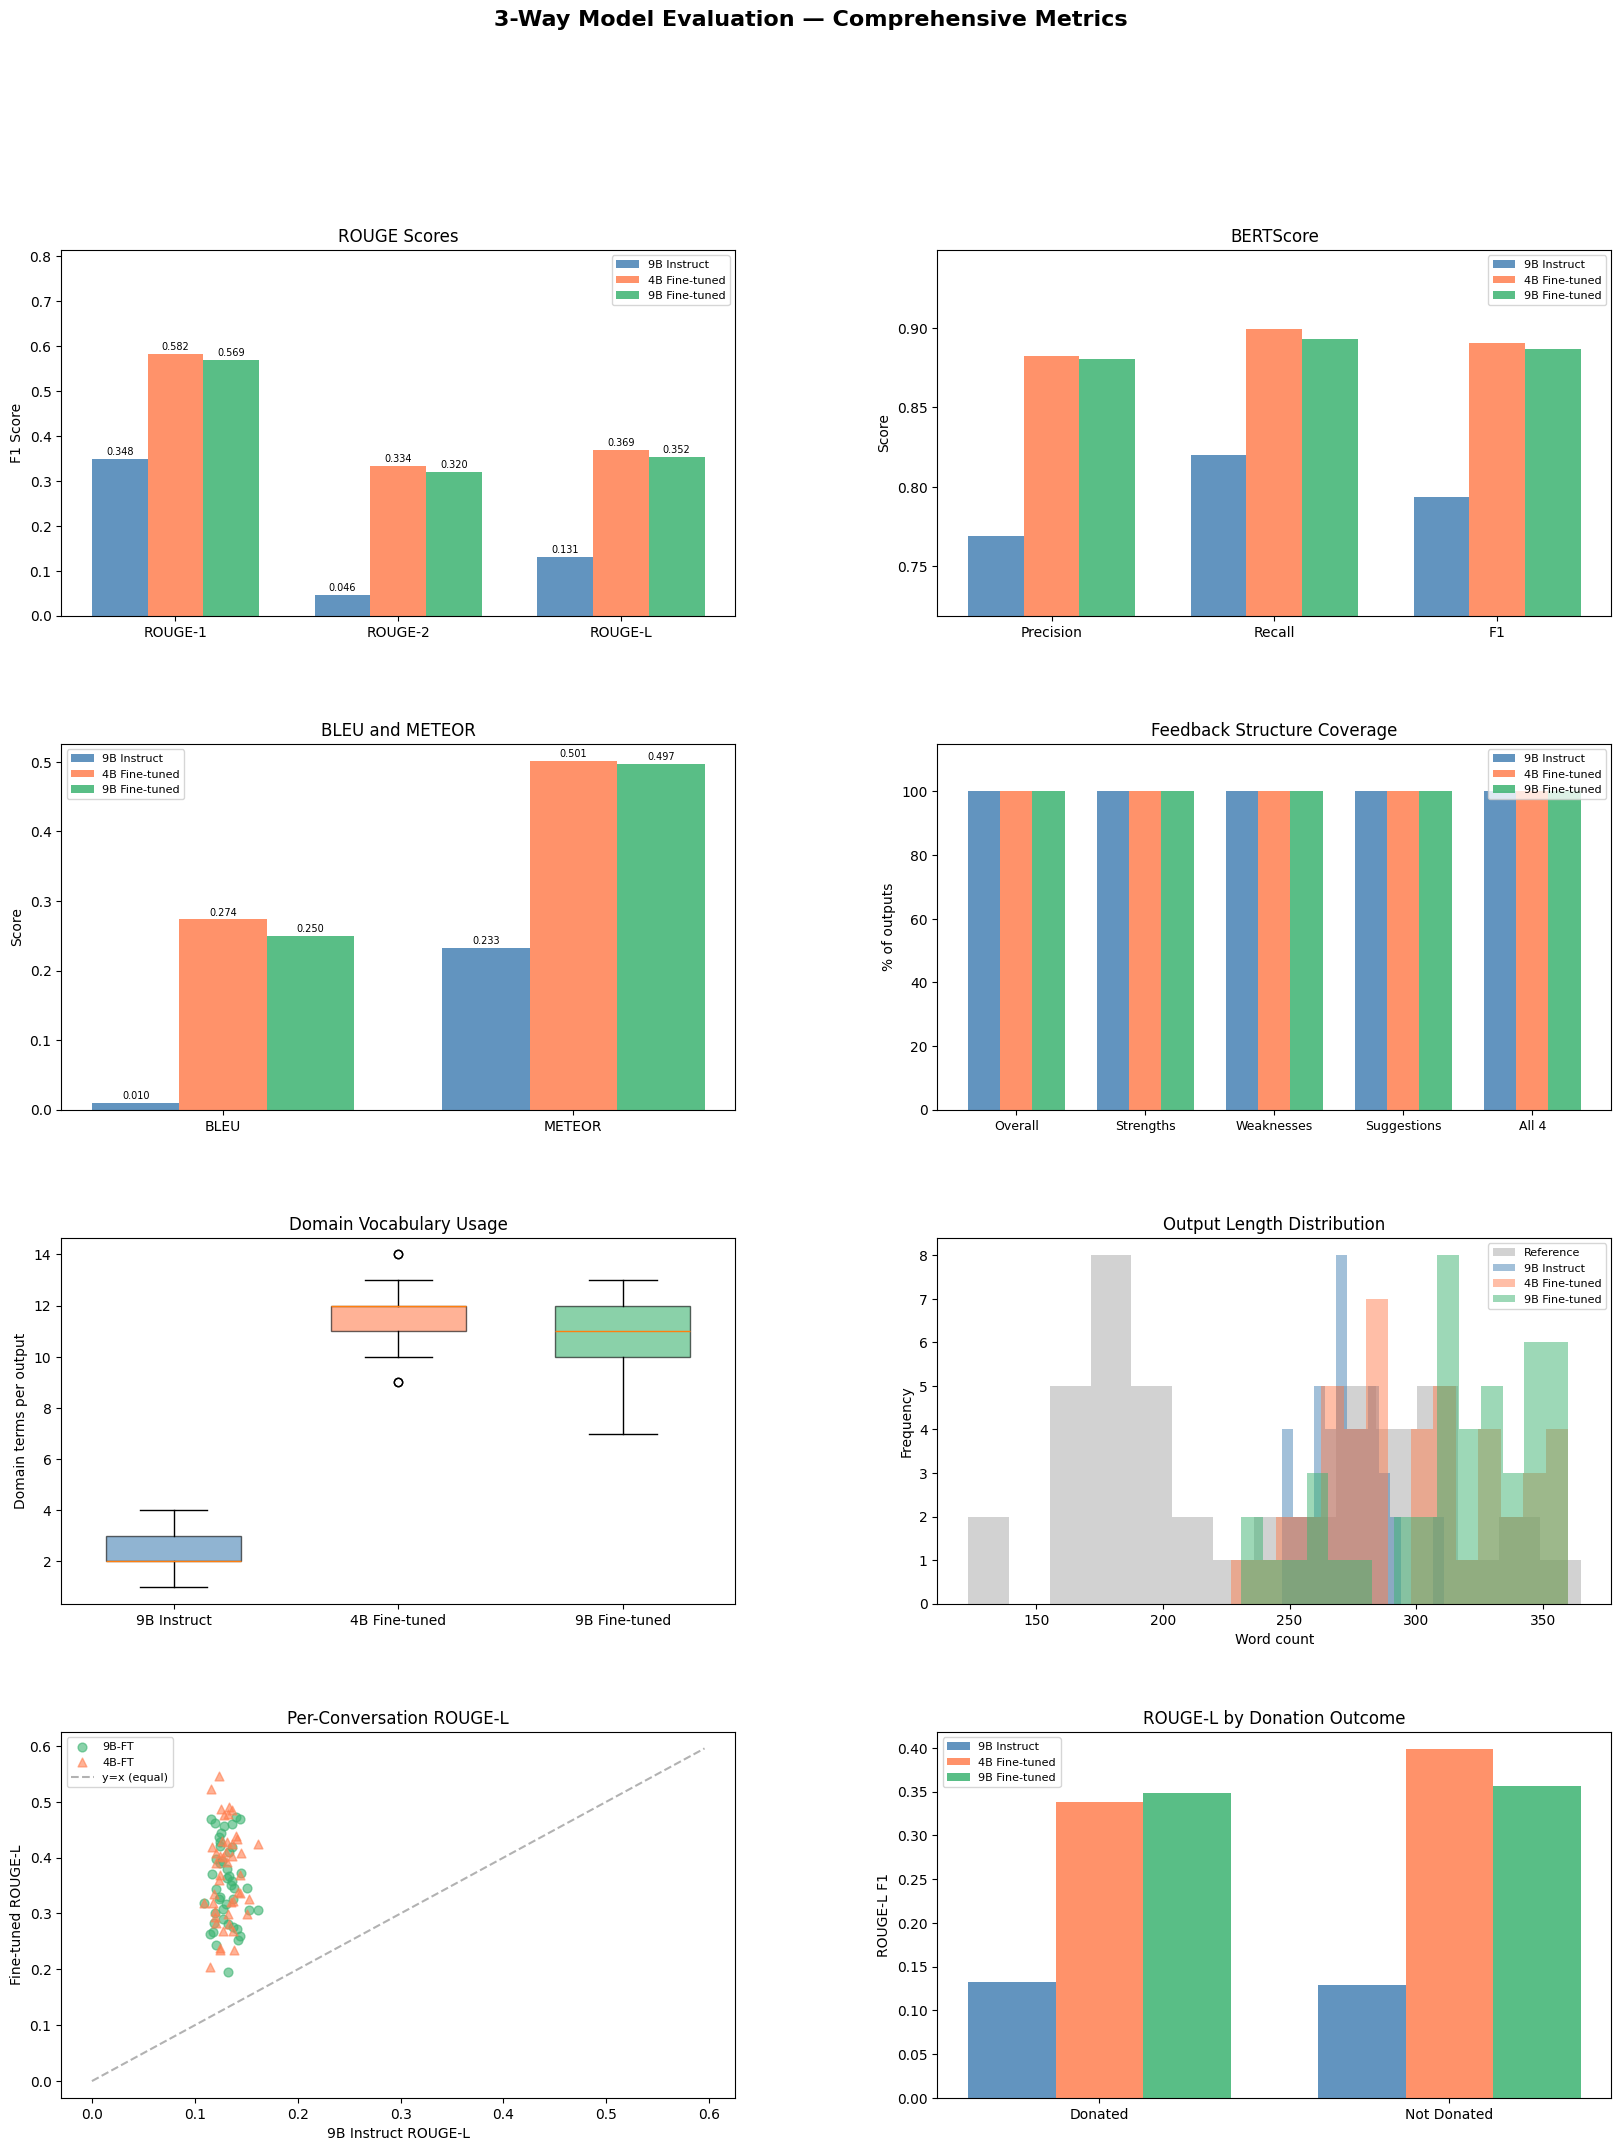

evaluation_comprehensive.png saved


In [18]:

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 24))
gs = GridSpec(4, 2, figure=fig, hspace=0.35, wspace=0.3)
fig.suptitle("3-Way Model Evaluation — Comprehensive Metrics", fontsize=16, fontweight='bold', y=0.98)

colors = ['steelblue', 'coral', 'mediumseagreen']
labels_m = ['9B Instruct', '4B Fine-tuned', '9B Fine-tuned']
w = 0.25

# ROUGE F1 scores
ax = fig.add_subplot(gs[0, 0])
metrics = ['ROUGE-1','ROUGE-2','ROUGE-L']
vals = [[rouge_summary[l][m] for m in ['rouge1','rouge2','rougeL']] for l in labels_m]
x = np.arange(len(metrics))
for j,(v,c,l) in enumerate(zip(vals,colors,labels_m)):
    ax.bar(x+j*w-w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylabel('F1 Score')
ax.set_title('ROUGE Scores'); ax.legend(fontsize=8)
ax.set_ylim(0, max(max(v) for v in vals)*1.4)
for j,(v,c) in enumerate(zip(vals,colors)):
    for xi,vi in zip(x,v): ax.text(xi+j*w-w, vi+0.005, f'{vi:.3f}', ha='center', va='bottom', fontsize=7)

# BERTScore
ax = fig.add_subplot(gs[0, 1])
metrics_bs = ['Precision','Recall','F1']
vals_bs = [[bertscore_summary[l][m] for m in ['precision','recall','f1']] for l in labels_m]
x2 = np.arange(len(metrics_bs))
for j,(v,c,l) in enumerate(zip(vals_bs,colors,labels_m)):
    ax.bar(x2+j*w-w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(metrics_bs); ax.set_ylabel('Score')
ax.set_title('BERTScore'); ax.legend(fontsize=8)
ax.set_ylim(min(min(v) for v in vals_bs)-0.05, max(max(v) for v in vals_bs)+0.05)

# BLEU + METEOR
ax = fig.add_subplot(gs[1, 0])
bm_metrics = ['BLEU','METEOR']
vals_bm = [[bleu_meteor_summary[l][m] for m in ['bleu','meteor']] for l in labels_m]
x3 = np.arange(len(bm_metrics))
for j,(v,c,l) in enumerate(zip(vals_bm,colors,labels_m)):
    ax.bar(x3+j*w-w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x3); ax.set_xticklabels(bm_metrics); ax.set_ylabel('Score')
ax.set_title('BLEU and METEOR'); ax.legend(fontsize=8)
for j,(v,c) in enumerate(zip(vals_bm,colors)):
    for xi,vi in zip(x3,v): ax.text(xi+j*w-w, vi+0.003, f'{vi:.3f}', ha='center', va='bottom', fontsize=7)

# Structural coverage
ax = fig.add_subplot(gs[1, 1])
struct_keys = ['overall_performance','what_worked','areas_for_improvement','suggestions','all_4_sections']
struct_short = ['Overall','Strengths','Weaknesses','Suggestions','All 4']
vals_s = [[s_bl[k] for k in struct_keys],[s_4b[k] for k in struct_keys],[s_9b[k] for k in struct_keys]]
x4 = np.arange(len(struct_short))
for j,(v,c,l) in enumerate(zip(vals_s,colors,labels_m)):
    ax.bar(x4+j*w-w, v, w, label=l, color=c, alpha=0.85)
ax.set_xticks(x4); ax.set_xticklabels(struct_short, fontsize=9); ax.set_ylabel('% of outputs')
ax.set_title('Feedback Structure Coverage'); ax.legend(fontsize=8); ax.set_ylim(0,115)

# Domain vocabulary
ax = fig.add_subplot(gs[2, 0])
dv_data = [dv_bl['per_output'], dv_4b['per_output'], dv_9b['per_output']]
bp = ax.boxplot(dv_data, labels=labels_m, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('Domain terms per output'); ax.set_title('Domain Vocabulary Usage')

# Word count distribution
ax = fig.add_subplot(gs[2, 1])
ax.hist(len_ref['raw'], bins=15, alpha=0.35, label='Reference', color='gray')
ax.hist(len_bl['raw'], bins=15, alpha=0.5, label='9B Instruct', color='steelblue')
ax.hist(len_4b['raw'], bins=15, alpha=0.5, label='4B Fine-tuned', color='coral')
ax.hist(len_9b['raw'], bins=15, alpha=0.5, label='9B Fine-tuned', color='mediumseagreen')
ax.set_xlabel('Word count'); ax.set_ylabel('Frequency'); ax.set_title('Output Length Distribution'); ax.legend(fontsize=8)

# Per-conversation ROUGE-L scatter
ax = fig.add_subplot(gs[3, 0])
ax.scatter(per_bl_rL, per_9b_rL, alpha=0.6, s=40, c='mediumseagreen', label='9B-FT', zorder=3)
ax.scatter(per_bl_rL, per_4b_rL, alpha=0.6, s=40, c='coral', marker='^', label='4B-FT', zorder=3)
mx = max(per_bl_rL.max(), per_9b_rL.max(), per_4b_rL.max()) + 0.05
ax.plot([0,mx],[0,mx],'k--',alpha=0.3,label='y=x (equal)')
ax.set_xlabel('9B Instruct ROUGE-L'); ax.set_ylabel('Fine-tuned ROUGE-L')
ax.set_title('Per-Conversation ROUGE-L'); ax.legend(fontsize=8)

# Per-outcome comparison
ax = fig.add_subplot(gs[3, 1])
outcomes = ['Donated','Not Donated']
bl_per_outcome = []
f4_per_outcome = []
f9_per_outcome = []
for idx_list in [donated_idx, not_donated_idx]:
    bl_per_outcome.append(np.mean([per_bl_rL[i] for i in idx_list]))
    f4_per_outcome.append(np.mean([per_4b_rL[i] for i in idx_list]))
    f9_per_outcome.append(np.mean([per_9b_rL[i] for i in idx_list]))
x5 = np.arange(len(outcomes))
ax.bar(x5-w, bl_per_outcome, w, label='9B Instruct', color='steelblue', alpha=0.85)
ax.bar(x5, f4_per_outcome, w, label='4B Fine-tuned', color='coral', alpha=0.85)
ax.bar(x5+w, f9_per_outcome, w, label='9B Fine-tuned', color='mediumseagreen', alpha=0.85)
ax.set_xticks(x5); ax.set_xticklabels(outcomes); ax.set_ylabel('ROUGE-L F1')
ax.set_title('ROUGE-L by Donation Outcome'); ax.legend(fontsize=8)

plt.savefig("evaluation_comprehensive.png", dpi=150, bbox_inches='tight')
plt.show()
print("evaluation_comprehensive.png saved")


In [19]:


print("=" * 80)
print("SIDE-BY-SIDE COMPARISON — SELECTED EXAMPLES")
print("=" * 80)

# best and worst for 9B-FT vs baseline
diffs = per_9b_rL - per_bl_rL
best_idx = np.argmax(diffs)
worst_idx = np.argmin(diffs)

for label, idx in [("BEST IMPROVEMENT (9B-FT >> Baseline)", best_idx),
                    ("WORST REGRESSION (9B-FT << Baseline)", worst_idx)]:
    did = common_ids[idx]
    outcome = "DONATED" if donated[idx] == 1 else "NOT DONATED"
    print(f"\n{'='*80}")
    print(f"{label}")
    print(f"Dialogue: {did} | Outcome: {outcome}")
    print(f"ROUGE-L: Baseline={per_bl_rL[idx]:.4f}  4B-FT={per_4b_rL[idx]:.4f}  9B-FT={per_9b_rL[idx]:.4f}")
    print(f"{'='*80}")

    print(f"\n--- REFERENCE (first 400 chars) ---")
    print(str(references[idx])[:400])
    print(f"\n--- 9B INSTRUCT BASELINE (first 400 chars) ---")
    print(str(baselines[idx])[:400])
    print(f"\n--- 4B FINE-TUNED (first 400 chars) ---")
    print(str(ft4bs[idx])[:400])
    print(f"\n--- 9B FINE-TUNED (first 400 chars) ---")
    print(str(ft9bs[idx])[:400])


SIDE-BY-SIDE COMPARISON — SELECTED EXAMPLES

BEST IMPROVEMENT (9B-FT >> Baseline)
Dialogue: 20180723-034654_121_live | Outcome: NOT DONATED
ROUGE-L: Baseline=0.1155  4B-FT=0.5236  9B-FT=0.4685

--- REFERENCE (first 400 chars) ---
OVERALL PERFORMANCE:
This persuasion conversation was unsuccessful — the persuadee did not donate. While the persuader made genuine efforts, the approach had gaps that prevented the persuadee from committing to a donation.

WHAT WORKED:
- Incorporated logical arguments and factual information about the cause, which helps persuadees who prefer evidence-based reasoning.
- Made emotional appeals to h

--- 9B INSTRUCT BASELINE (first 400 chars) ---
Thinking Process:

1.  **Analyze the Request:**
    *   **Role:** Expert Communication Coach specializing in charitable persuasion conversations.
    *   **Task:** Analyze a provided conversation between a Persuader (trying to get someone to donate to Save the Children) and a Persuadee.
    *   **Output Structure:**
   

In [20]:


print("=" * 85)
print("FINAL EVALUATION SUMMARY")
print("=" * 85)
print(f"\nTest set: {len(common_ids)} conversations ({len(donated_idx)} donated, {len(not_donated_idx)} not donated)")

print(f"\n{'Metric':<24} {'9B Instruct':>14} {'4B Fine-tuned':>14} {'9B Fine-tuned':>14} {'Best':>12}")
print("-" * 85)

all_metrics = [
    ("ROUGE-1 F1", rouge_summary['9B Instruct']['rouge1'], rouge_summary['4B Fine-tuned']['rouge1'], rouge_summary['9B Fine-tuned']['rouge1']),
    ("ROUGE-2 F1", rouge_summary['9B Instruct']['rouge2'], rouge_summary['4B Fine-tuned']['rouge2'], rouge_summary['9B Fine-tuned']['rouge2']),
    ("ROUGE-L F1", rouge_summary['9B Instruct']['rougeL'], rouge_summary['4B Fine-tuned']['rougeL'], rouge_summary['9B Fine-tuned']['rougeL']),
    ("BERTScore F1", bertscore_summary['9B Instruct']['f1'], bertscore_summary['4B Fine-tuned']['f1'], bertscore_summary['9B Fine-tuned']['f1']),
    ("BLEU", bleu_meteor_summary['9B Instruct']['bleu'], bleu_meteor_summary['4B Fine-tuned']['bleu'], bleu_meteor_summary['9B Fine-tuned']['bleu']),
    ("METEOR", bleu_meteor_summary['9B Instruct']['meteor'], bleu_meteor_summary['4B Fine-tuned']['meteor'], bleu_meteor_summary['9B Fine-tuned']['meteor']),
    ("Structure (all 4)", s_bl['all_4_sections'], s_4b['all_4_sections'], s_9b['all_4_sections']),
    ("Domain vocab (avg)", dv_bl['avg_domain_terms'], dv_4b['avg_domain_terms'], dv_9b['avg_domain_terms']),
    ("Avg words", len_bl['mean'], len_4b['mean'], len_9b['mean']),
]

wins = {'9B Instruct':0, '4B Fine-tuned':0, '9B Fine-tuned':0}
for name, bl, f4, f9 in all_metrics:
    best_val = max(bl, f4, f9)
    # For avg words, closer to reference is better
    if name == "Avg words":
        ref_wc = len_ref['mean']
        dists = {'9B Instruct':abs(bl-ref_wc), '4B Fine-tuned':abs(f4-ref_wc), '9B Fine-tuned':abs(f9-ref_wc)}
        best_name = min(dists, key=dists.get)
    else:
        scores = {'9B Instruct':bl, '4B Fine-tuned':f4, '9B Fine-tuned':f9}
        best_name = max(scores, key=scores.get)
    wins[best_name] += 1
    print(f"{name:<24} {bl:>14.4f} {f4:>14.4f} {f9:>14.4f} {best_name:>12}")

print(f"\n{'Metric wins':<24} {wins['9B Instruct']:>14} {wins['4B Fine-tuned']:>14} {wins['9B Fine-tuned']:>14}")

# report
report = {
    "experiment": "3-Way Evaluation: 9B Instruct vs 4B Fine-tuned vs 9B Fine-tuned",
    "test_conversations": len(common_ids),
    "donated_count": len(donated_idx),
    "not_donated_count": len(not_donated_idx),
    "rouge": rouge_summary,
    "bertscore": bertscore_summary,
    "bleu_meteor": bleu_meteor_summary,
    "structural_quality": {"9B Instruct":s_bl, "4B Fine-tuned":s_4b, "9B Fine-tuned":s_9b},
    "domain_vocabulary": {
        "9B Instruct": {"avg_terms":dv_bl['avg_domain_terms'], "zero_term_outputs":dv_bl['outputs_with_0_terms']},
        "4B Fine-tuned": {"avg_terms":dv_4b['avg_domain_terms'], "zero_term_outputs":dv_4b['outputs_with_0_terms']},
        "9B Fine-tuned": {"avg_terms":dv_9b['avg_domain_terms'], "zero_term_outputs":dv_9b['outputs_with_0_terms']},
    },
    "length": {
        "Reference": {"mean":len_ref['mean'],"median":len_ref['median']},
        "9B Instruct": {"mean":len_bl['mean'],"median":len_bl['median']},
        "4B Fine-tuned": {"mean":len_4b['mean'],"median":len_4b['median']},
        "9B Fine-tuned": {"mean":len_9b['mean'],"median":len_9b['median']},
    },
    "metric_wins": wins,
}

with open("evaluation_report_full.json", "w") as f:
    json.dump(report, f, indent=2)

print(f"\nevaluation_report_full.json saved")
print("evaluation_comprehensive.png saved")
print("\nDone. All evaluation complete.")


FINAL EVALUATION SUMMARY

Test set: 45 conversations (22 donated, 23 not donated)

Metric                      9B Instruct  4B Fine-tuned  9B Fine-tuned         Best
-------------------------------------------------------------------------------------
ROUGE-1 F1                       0.3478         0.5820         0.5690 4B Fine-tuned
ROUGE-2 F1                       0.0458         0.3339         0.3198 4B Fine-tuned
ROUGE-L F1                       0.1305         0.3693         0.3523 4B Fine-tuned
BERTScore F1                     0.7937         0.8908         0.8868 4B Fine-tuned
BLEU                             0.0096         0.2735         0.2503 4B Fine-tuned
METEOR                           0.2328         0.5010         0.4974 4B Fine-tuned
Structure (all 4)              100.0000       100.0000       100.0000  9B Instruct
Domain vocab (avg)               2.5100        11.6000        10.9800 4B Fine-tuned
Avg words                      272.4000       299.6000       314.4000  9B Ins